# Lab1: End - to - end ML regression

**Step1:** Get the data

In [8]:
# Data is attached to the notebook uploaded
import pandas as pd
housing_data = pd.read_csv('housing.csv')

In [9]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Step2:** Data discovery

In [10]:
housing_data.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [11]:
housing_data.shape

(20640, 10)

In [12]:
housing_data.size

206400

In [13]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [14]:
housing_data['total_bedrooms'].isnull().sum()

207

In [15]:
100*housing_data['total_bedrooms'].isnull().value_counts(normalize=True)

total_bedrooms
False    98.997093
True      1.002907
Name: proportion, dtype: float64

In [16]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [17]:
housing_data.describe(include='object')

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


In [18]:
housing_data.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

### Visualization

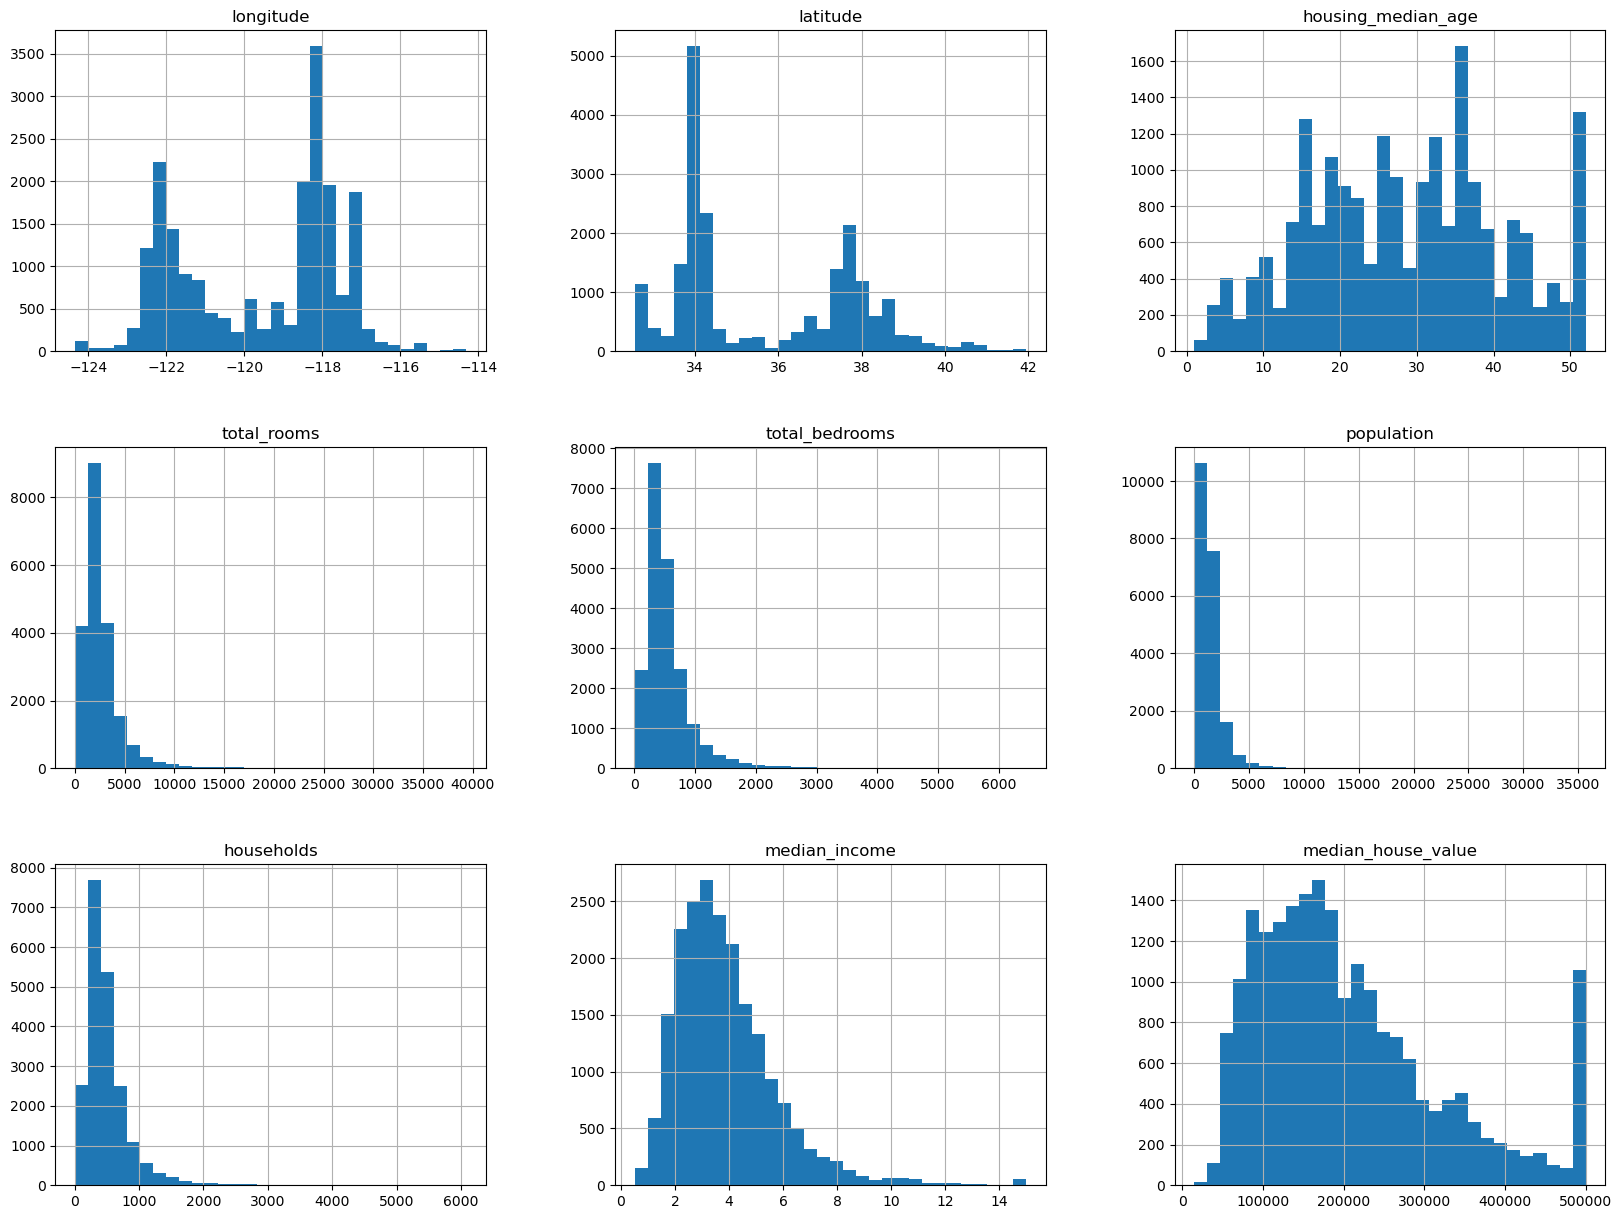

In [19]:
housing_data.hist(bins=30, figsize=(20,15));

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

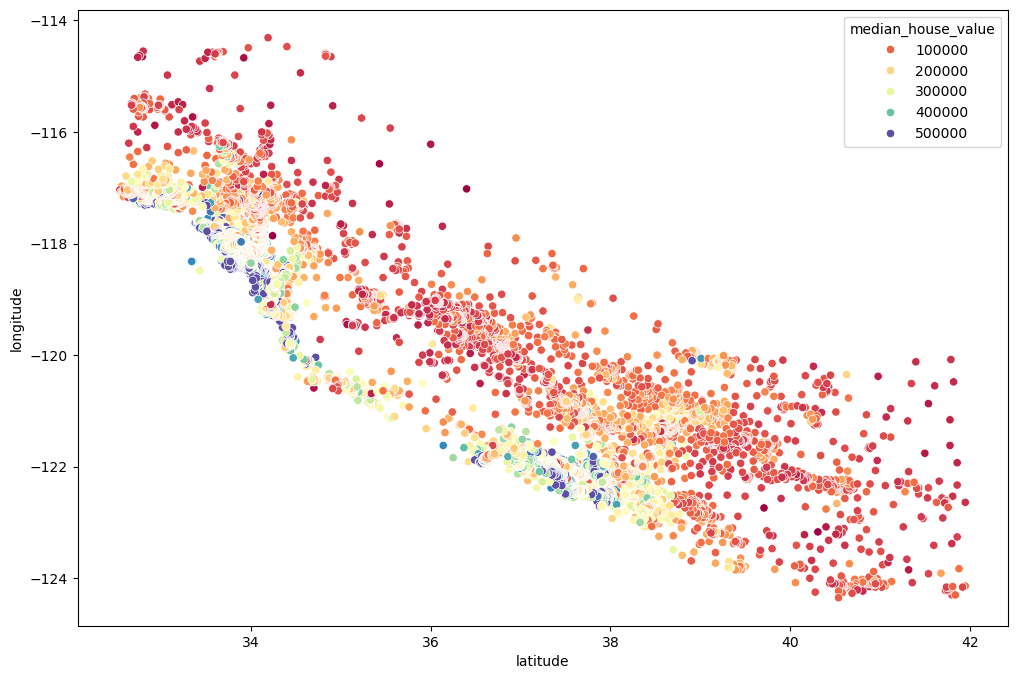

In [21]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=housing_data, x='latitude', y='longitude',hue='median_house_value', palette='Spectral');

### Data correlation

In [22]:
# Exclude the last column
corr_mat=housing_data.drop('ocean_proximity', axis=1).corr()

In [23]:
corr_mat

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [24]:
corr_mat['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [25]:
attributes=['median_house_value','median_income','total_rooms','housing_median_age']
sub_df = housing_data[attributes]
sub_df.head()

,median_house_value,median_income,total_rooms,housing_median_age
0,452600.0,8.3252,880.0,41.0
1,358500.0,8.3014,7099.0,21.0
2,352100.0,7.2574,1467.0,52.0
3,341300.0,5.6431,1274.0,52.0
4,342200.0,3.8462,1627.0,52.0


d:\MiniMiniConda\envs\MSE413\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


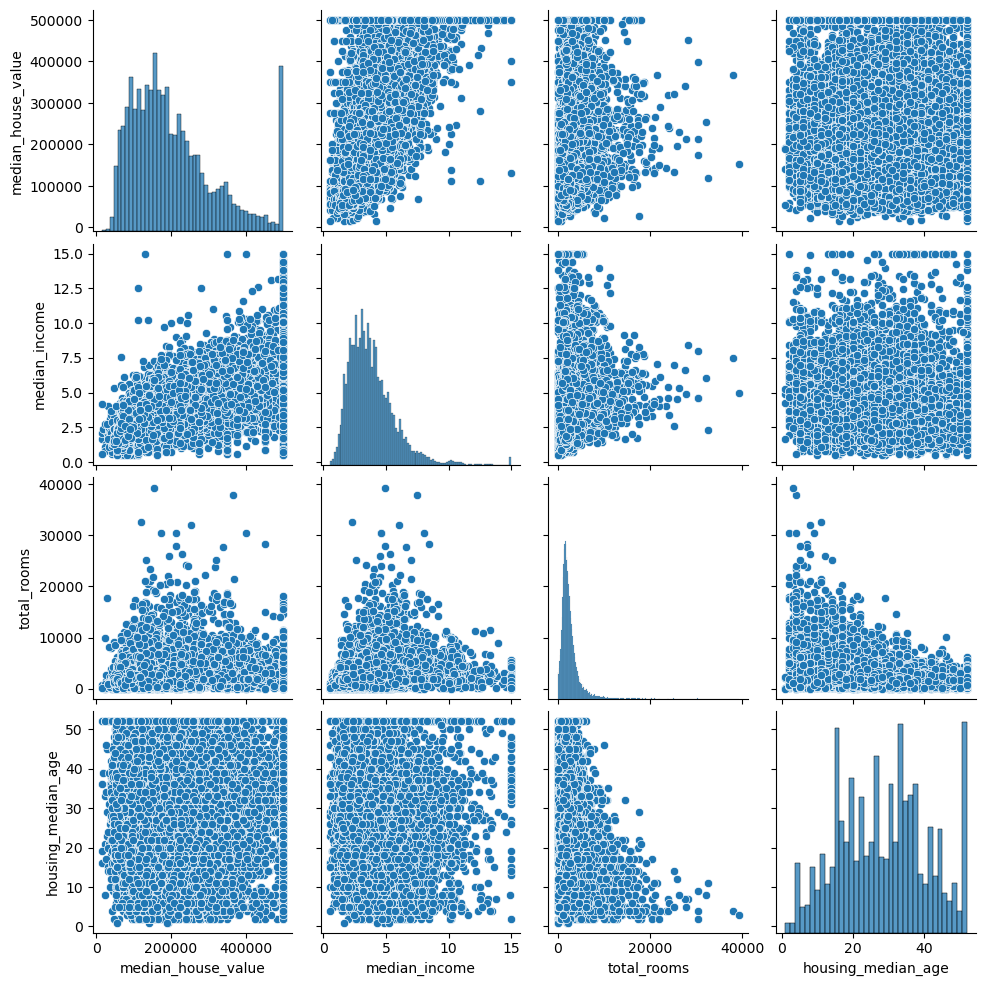

In [26]:
sns.pairplot(data=sub_df);

In [27]:
housing_data[housing_data.housing_median_age>=50]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20235,-119.27,34.28,50.0,1710.0,412.0,915.0,380.0,3.1757,206300.0,NEAR OCEAN
20236,-119.27,34.27,52.0,459.0,112.0,276.0,107.0,2.3750,198400.0,NEAR OCEAN
20237,-119.27,34.27,52.0,1577.0,343.0,836.0,335.0,3.5893,206600.0,NEAR OCEAN
20443,-118.85,34.27,50.0,187.0,33.0,130.0,35.0,3.3438,500001.0,<1H OCEAN


<Axes: xlabel='ocean_proximity', ylabel='median_house_value'>

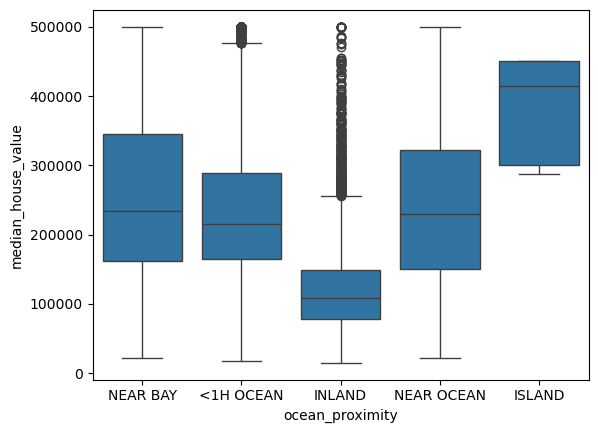

In [28]:
sns.boxplot(data=housing_data, x='ocean_proximity',y='median_house_value')

### Feature extraction

In [29]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# Copy everything except ocean_proximity
housing_data_sub=housing_data.copy()

In [31]:
attributes=['total_rooms','total_bedrooms','population','households']
sub_df = housing_data[attributes]
sub_df.head()

,total_rooms,total_bedrooms,population,households
0,880.0,129.0,322.0,126.0
1,7099.0,1106.0,2401.0,1138.0
2,1467.0,190.0,496.0,177.0
3,1274.0,235.0,558.0,219.0
4,1627.0,280.0,565.0,259.0


d:\MiniMiniConda\envs\MSE413\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


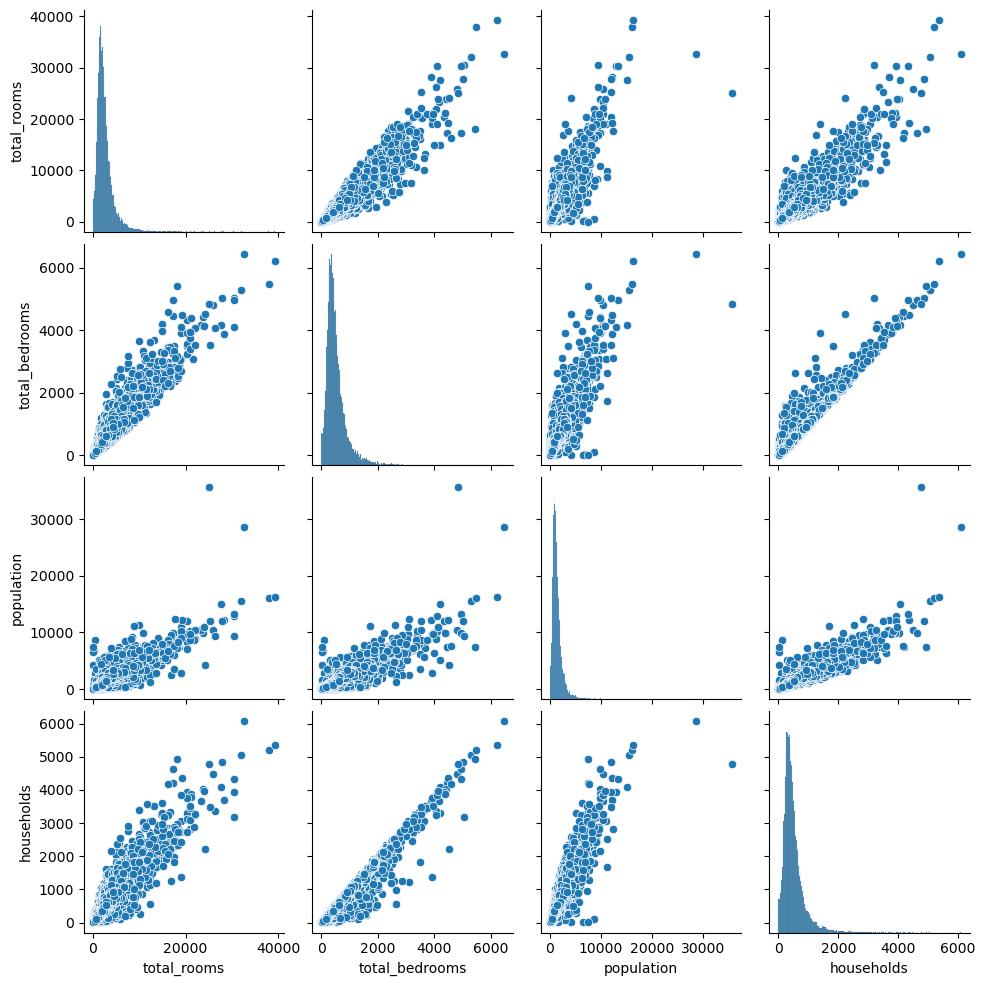

In [32]:
sns.pairplot(sub_df);

In [33]:
housing_data_sub['bedroom_per_room'] = housing_data_sub.total_bedrooms/housing_data_sub.total_rooms
housing_data_sub['bedroom_per_household'] = housing_data_sub.total_bedrooms/housing_data_sub.households
housing_data_sub['room_per_household'] = housing_data_sub.total_rooms/housing_data_sub.households
housing_data_sub['population_per_household'] = housing_data_sub.population/housing_data_sub.households

In [ ]:
# Remove Ocent Proximity columns, the last one
corr_mat = housing_data_sub.drop(columns="ocean_proximity").corr()

In [39]:
corr_mat

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,bedroom_per_room,bedroom_per_household,room_per_household,population_per_household
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967,0.092657,0.013402,-0.027540,0.002476
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160,-0.113815,0.070025,0.106389,0.002366
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623,0.136089,-0.077918,-0.153277,0.013191
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153,-0.187900,0.029373,0.133798,-0.024581
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.084238,0.045887,0.001538,-0.028355
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650,0.035319,-0.066510,-0.072213,0.069863
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843,0.065087,-0.055158,-0.080598,-0.027309
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075,-0.615661,-0.062299,0.326895,0.018766
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000,-0.255880,-0.046739,0.151948,-0.023737
bedroom_per_room,0.092657,-0.113815,0.136089,-0.187900,0.084238,0.035319,0.065087,-0.615661,-0.255880,1.000000,0.055905,-0.416952,0.002938


In [148]:
corr_mat['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
room_per_household          0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
bedroom_per_household      -0.046739
latitude                   -0.144160
bedroom_per_room           -0.255880
Name: median_house_value, dtype: float64

In [149]:
housing_data = housing_data.drop(labels=['total_rooms','housing_median_age'],axis=1)


In [150]:
housing_data['room_per_household'] = housing_data_sub.room_per_household
housing_data['bedroom_per_room'] = housing_data_sub.bedroom_per_room
housing_data.head()

,longitude,latitude,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,room_per_household,bedroom_per_room
0,-122.23,37.88,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591
1,-122.22,37.86,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797
2,-122.24,37.85,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516
3,-122.25,37.85,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458
4,-122.25,37.85,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096


In [151]:
housing_data=housing_data.dropna(subset='total_bedrooms',axis=0)

In [152]:
housing_data.isna().sum()

longitude             0
latitude              0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
room_per_household    0
bedroom_per_room      0
dtype: int64

In [153]:
housing_data.shape

(20433, 10)

In [154]:
housing_data_backup = housing_data.copy()

### One-Hot-Encoding

In [155]:
# Encoding using Pandas

In [156]:
housing_data_encoded=pd.get_dummies(housing_data,drop_first=True)

In [157]:
housing_data_encoded.head()

,longitude,latitude,total_bedrooms,population,households,median_income,median_house_value,room_per_household,bedroom_per_room,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,0,0,1,0
1,-122.22,37.86,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,0,0,1,0
2,-122.24,37.85,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,0,0,1,0
3,-122.25,37.85,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,0,0,1,0
4,-122.25,37.85,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,0,0,1,0


In [158]:
# Encoding using Scikit-learn

In [159]:
housing_cat = housing_data[['ocean_proximity']]

In [160]:
from sklearn.preprocessing import OneHotEncoder
OHE = OneHotEncoder()
housing_data_encoded_sk = OHE.fit_transform(housing_cat).toarray()

In [161]:
housing_data_encoded_sk[1:10]

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.]])

In [162]:
OHE.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [163]:
pd.DataFrame(data=housing_data_encoded_sk, columns=OHE.categories_)

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...
20428,0.0,1.0,0.0,0.0,0.0
20429,0.0,1.0,0.0,0.0,0.0
20430,0.0,1.0,0.0,0.0,0.0
20431,0.0,1.0,0.0,0.0,0.0


In [164]:
housing_data_encoded.describe()

,longitude,latitude,total_bedrooms,population,households,median_income,median_house_value,room_per_household,bedroom_per_room,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,537.870553,1424.946949,499.433465,3.871162,206864.413155,5.431344,0.213039,0.317917,0.000245,0.111095,0.128615
std,2.003578,2.136348,421.385070,1133.208490,382.299226,1.899291,115435.667099,2.482946,0.057983,0.465678,0.015641,0.314257,0.334782
min,-124.350000,32.540000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.100000,0.000000,0.000000,0.000000,0.000000
25%,-121.800000,33.930000,296.000000,787.000000,280.000000,2.563700,119500.000000,4.441441,0.175427,0.000000,0.000000,0.000000,0.000000
50%,-118.490000,34.260000,435.000000,1166.000000,409.000000,3.536500,179700.000000,5.230769,0.203162,0.000000,0.000000,0.000000,0.000000
75%,-118.010000,37.720000,647.000000,1722.000000,604.000000,4.744000,264700.000000,6.052381,0.239821,1.000000,0.000000,0.000000,0.000000
max,-114.310000,41.950000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,1.000000,1.000000,1.000000,1.000000,1.000000


### Data scaling

In [165]:
from sklearn.preprocessing import StandardScaler
X= housing_data_encoded.drop('median_house_value',axis=1)
Y = housing_data_encoded.median_house_value
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

In [166]:
X_scaled.head()

,longitude,latitude,total_bedrooms,population,households,median_income,room_per_household,bedroom_per_room,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327314,1.051717,-0.970325,-0.973320,-0.976833,2.345163,0.625395,-1.146024,-0.682713,-0.015645,2.828661,-0.384186
1,-1.322323,1.042355,1.348276,0.861339,1.670373,2.332632,0.324942,-0.987254,-0.682713,-0.015645,2.828661,-0.384186
2,-1.332305,1.037674,-0.825561,-0.819769,-0.843427,1.782939,1.150594,-1.440514,-0.682713,-0.015645,2.828661,-0.384186
3,-1.337296,1.037674,-0.718768,-0.765056,-0.733562,0.932970,0.155467,-0.492925,-0.682713,-0.015645,2.828661,-0.384186
4,-1.337296,1.037674,-0.611974,-0.758879,-0.628930,-0.013143,0.342549,-0.706141,-0.682713,-0.015645,2.828661,-0.384186


In [167]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X_scaled,Y,test_size=0.2,random_state=42)

In [168]:
X_train.shape

(16346, 12)

In [169]:
X_test.shape

(4087, 12)

In [222]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
model = LR.fit(X_train,Y_train)

In [223]:
pd.DataFrame(data=model.coef_,index=list(X_train.columns),columns=['coefficients'])

,coefficients
longitude,-61581.347030
latitude,-62256.982557
total_bedrooms,5289.612148
population,-43835.945241
households,38885.713360
median_income,76227.697662
room_per_household,8043.376625
bedroom_per_room,16057.405722
ocean_proximity_INLAND,-17504.250979
ocean_proximity_ISLAND,3435.849905


### Performance measurement

In [224]:
Y_pred = model.predict(X_train)

In [225]:
Y_pred[:5]

array([263551.46826892, 118983.73446618, 183993.91597901, 196053.95456868,
       202207.72009068])

In [226]:
from sklearn.metrics import r2_score, mean_squared_error

In [227]:
r_sq = r2_score(Y_train,Y_pred)
rmse = (mean_squared_error(Y_train,Y_pred))**0.5

In [228]:
print(f"R-squarred :{r_sq:>3.2f}")
print(f"Root-mean-squarred-error:{rmse:>3.2f}")

R-squarred :0.64
Root-mean-squarred-error:68712.57


### Non-liear model training

In [177]:
from sklearn.preprocessing import PolynomialFeatures

In [209]:
Poly_transformer = PolynomialFeatures(degree=2,include_bias=False).fit(X_train)

In [210]:
X_train_transformed=Poly_transformer.transform(X_train)

In [218]:
model_2=LR.fit(X_train_transformed,Y_train)

In [219]:
Y_pred=model_2.predict(X_train_transformed)

In [221]:
r_sq = r2_score(Y_train,Y_pred)
rmse = (mean_squared_error(Y_train,Y_pred))**0.5
print(f"R-squarred :{r_sq:>3.2f}")
print(f"Root-mean-squarred-error:{rmse:>3.2f}")

R-squarred :0.70
Root-mean-squarred-error:62645.15


In [ ]:
from sklearn.tree import DecisionTreeRegressor
model_tree = DecisionTreeRegressor(random_state=32).fit(X_train,Y_train)

In [ ]:
Y_pred = model_tree.predict(X_train)

In [ ]:
r_sq = r2_score(Y_train,Y_pred)
rmse = (mean_squared_error(Y_train,Y_pred))**0.5
print(f"R-squarred :{r_sq:>3.2f}")
print(f"Root-mean-squarred-error:{rmse:>3.2f}")

### Cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score
tree_rmse = - cross_val_score(DecisionTreeRegressor(random_state=32),X_train,Y_train,scoring="neg_root_mean_squared_error"
                             ,cv=5)

In [ ]:
pd.Series(tree_rmse).describe()